## 2 langgraph控制流与节点执行
本质就是边

{'username': '小黄', 'greeting': 'Dear 小黄', 'output': 'Dear 小黄，你好！'}


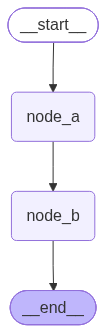

In [4]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END


class OverAllState(TypedDict):
    username: str
    greeting: str
    output: str


def node_a(state: OverAllState) -> OverAllState:
    return {
        "greeting": "Dear " + state["username"]
    }


def node_b(state: OverAllState) -> OverAllState:
    return {
        "output": state["greeting"] + "，你好！"
    }


builder = StateGraph(state_schema=OverAllState)
# builder.add_node("node_a", node_a)
# builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
# builder.add_edge("node_a", "node_b")
builder.add_sequence([node_a, node_b])
builder.add_edge("node_b", END)

graph = builder.compile()
res = graph.invoke({"username": "小黄"})
print(res)

from IPython.display import display

display(graph)